# 第10章 畳み込みネットワーク (Convolutional Networks)
## 10.1 コンピュータビジョン (Computer Vision)

本ノートブックは、Christopher M. Bishop & Hugh Bishop (2024)『深層学習：基礎と概念 (Deep Learning: Foundations and Concepts)』第10章「畳み込みネットワーク」第10.1節「コンピュータビジョン (Computer Vision)」および第10.1.1節「画像データ (Image data)」の理論的背景、数学的定式化、Python実装、および忠実な可視化を提供します。

---

### 目次
1. **10.1 コンピュータビジョンの概要と10大タスク (Computer Vision & 10 Canonical Tasks)**
   - 歴史的変遷：射影幾何・手作業特徴量から深層畳み込みネットワークへのパラダイムシフト
   - 教科書で提示される代表的な10大タスクの分類体系
   - 図版: 10大タスクのアーキテクチャ・入出力マッピング分類図
2. **10.1.1 画像データの数学的表現と次元性 (Image Data Representation & Dimensionality)**
   - 2D画像、RGBカラーチャネルテンソル $(H \times W \times C)$
   - ITU-R BT.601 規格による輝度（Grayscale）変換の数学的定義
   - 3Dデータへの拡張：MRIボクセル $(D \times H \times W)$ と動画テンソル $(T \times H \times W \times C)$
   - 図版: RGBチャネル分解とピクセル強度グリッド
3. **無構造MLPの破綻と構造的帰納バイアスの必然性**
   - 次元の呪い：$1000 \times 1000 \times 3$ 入力と第1層重み数 $3 \times 10^9$ の爆発
   - 置換不変性（Permutation Invariance）の致命的欠陥：画素並べ替えに対するMLPの等価性と視覚構造の破壊
   - 独立一様ノイズと自然画像多様体の希薄性
4. **自然画像の局所空間相関（Spatial Autocorrelation）の定式化と検証**
   - 空間自己相関関数 $C(\Delta x)$ の厳密な数学的導出
   - 実験検証：自然画像 vs 画素置換画像 vs 白色ノイズの自己相関減衰挙動
   - 図版: 局所自己相関関数の比較プロット
5. **畳み込みネットワーク（CNN）の設計原理への架橋**
   - 局所受容野（Local Receptive Fields）によるパラメータ削減
   - 重み共有（Weight Sharing）と統計的効率
   - 並進等変性（Translation Equivariance）
6. **演習・数値検証セル**
7. **まとめと次節 10.2 への展開**


In [1]:
import sys
import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# プロジェクトルートを Python パスに追加
repo_root = Path("..").resolve()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from common.plot_utils import setup_style
setup_style()


## 1. 10.1 コンピュータビジョンの概要と10大タスク

コンピュータビジョン（Computer Vision）は、画像や映像などの視覚データを自動的に解析・解釈する学問領域であり、機械学習の最大の応用分野の一つです（Szeliski, 2022）。

### 歴史的背景とパラダイムシフト
歴史的に、古典的コンピュータビジョンは**3次元射影幾何学（3-dimensional projective geometry）**と、人間が手作業で設計した特徴量（SIFT, SURF, HOGなど）を入力とする浅い学習アルゴリズム（SVM, ランダムフォレストなど）に強く依存していました（Hartley and Zisserman, 2004）。

しかし、深層畳み込みニューラルネットワーク（CNN: Convolutional Neural Network）の台頭（Krizhevsky et al., 2012; LeCun et al., 1989）によって、生のピクセルから階層的な特徴表現をエンド・ツー・エンドで学習するアプローチへと完全に移行しました。

### 教科書（Section 10.1）に挙げられる10大タスク

| 番号 | タスク名 | 入力 $\to$ 出力 | 代表的応用例 | 教科書参照 |
|:---:|:---|:---|:---|:---:|
| **1** | **画像分類 (Classification)** | $I \in \mathbb{R}^{H \times W \times C} \to y \in \{1, \dots, K\}$ | 病変の良性/悪性判定、物体カテゴリ認識 | Figure 1.1 |
| **2** | **物体検出 (Object Detection)** | $I \to \{(b_i, c_i, s_i)\}_{i=1}^M$ | 自動運転における歩行者・車両検知 | Figure 10.19 |
| **3** | **セグメンテーション (Segmentation)** | $I \to S \in \{1, \dots, K\}^{H \times W}$ | 医療画像における腫瘍領域分割、道路領域抽出 | Figure 10.26 |
| **4** | **画像キャプション生成 (Captioning)** | $I \to \mathbf{w} = (w_1, \dots, w_T)$ | 視覚障害者向け画像説明、マルチモーダル検索 | Figure 12.27 |
| **5** | **画像生成 (Image Synthesis)** | $\mathbf{z} \sim \mathcal{N}(\mathbf{0}, \mathbf{I}) \to I$ (または テキスト $\to I$) | 人物顔画像生成、拡散モデルによる画像生成 | Figure 1.3 |
| **6** | **インペインティング (Inpainting)** | $(I_{\text{masked}}, M) \to I_{\text{restored}}$ | 不要物体の除去、欠損写真の修復 | Figure 20.9 |
| **7** | **画風変換 (Style Transfer)** | $(I_{\text{content}}, I_{\text{style}}) \to I_{\text{styled}}$ | 写真の絵画調変換（Gatys et al., 2016） | Figure 10.32 |
| **8** | **超解像 (Super-Resolution)** | $I_{\text{low-res}} \to I_{\text{high-res}}$ | 高精細画像復元、高周波成分の合成 | Figure 20.8 |
| **9** | **深度予測 (Depth Prediction)** | $I \to D \in \mathbb{R}^{H \times W}$ (距離マップ) | 単眼深度推定、自律ロボットのナビゲーション | - |
| **10** | **3次元シーン復元 (Scene Reconstruction)** | $\{I_k\}_{k=1}^K \to 3\text{D Model}$ (NeRF, 3DGS) | 2D画像群からの3D幾何形状・放射輝度場復元 | - |


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/fig_10_computer_vision_taxonomy.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_10_computer_vision_taxonomy.png


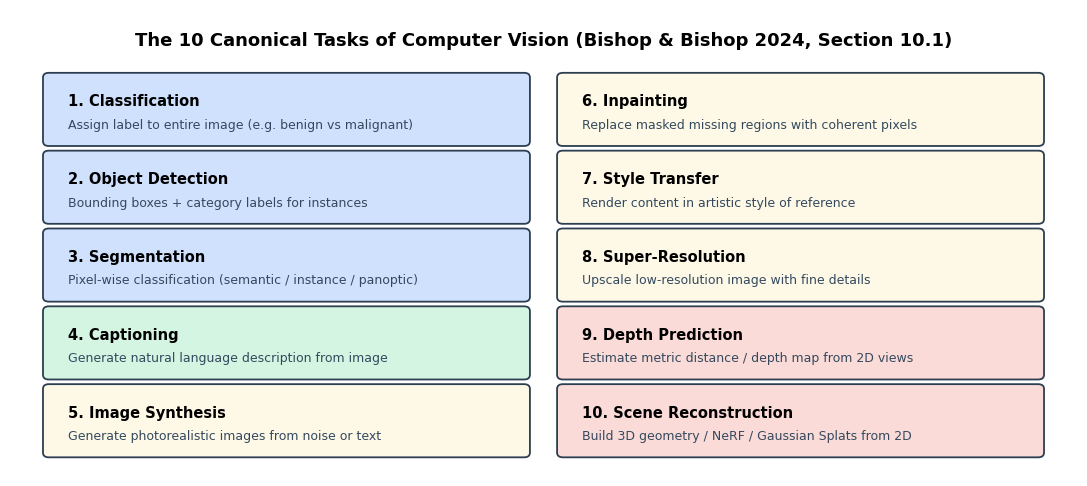

In [2]:
# 10大タスクの分類体系図の生成と表示
from common.computer_vision import generate_figure_cv_taxonomy
import matplotlib.pyplot as plt

fig = generate_figure_cv_taxonomy()
plt.show()


### 10大タスクの構造的分析

上図に示すように、コンピュータビジョンのタスクは大きく4つのカテゴリーに分類されます：
1. **意味的抽象化・識別タスク (Recognition & Parsing)**:
   - 分類（1）、検出（2）、セグメンテーション（3）は、高次元の画像空間から離散的なラベルや領域情報を抽出するタスクであり、低次特徴から高次意味論への**情報の集約（空間的プーリング）**を特徴とします。
2. **言語・マルチモーダル変換 (Vision-Language)**:
   - キャプション生成（4）は、CNNなどの視覚バックボーンとTransformerなどの言語モデルを接続し、視覚特徴から文脈的自然言語シーケンスへと変換します。
3. **低レベル視覚・画像再構成 (Image-to-Image / Generation)**:
   - 画像生成（5）、インペインティング（6）、画風変換（7）、超解像（8）は、出力が再び高次元画像テンソルとなるタスクです。高周波テクスチャの保持と大域的一貫性の両立が要求されます。
4. **3次元幾何・物理空間推定 (3D Vision & Geometry)**:
   - 深度予測（9）やシーン再構成（10）は、2次元網膜像から物理的な3次元世界の幾何学的構造（距離、カメラ姿勢、表面法線、放射輝度場）を逆推定するイルポーズドな逆問題（Ill-posed inverse problem）を扱います。


## 2. 10.1.1 画像データの数学的表現と次元性

### 画像テンソルの形式
デジタル画像は、離散的なピクセル（Pixel: Picture Element）の長方形2次元配列として定義されます。
一般に、カラー画像は高さ $H$、幅 $W$、およびチャネル数 $C$（赤 $R$、緑 $G$、青 $B$ の3チャネル）からなる3階テンソルとして表現されます：

$$\mathbf{I} \in \mathbb{R}^{H \times W \times C}, \quad I_{i, j, c} \in [0, 1] \quad (\text{または } \{0, 1, \dots, 255\})$$

ここで、座標 $(i, j)$ はそれぞれ行（垂直方向位置 $i \in \{1, \dots, H\}$）と列（水平方向位置 $j \in \{1, \dots, W\}$）を表し、$c \in \{0, 1, 2\}$ は色チャネルのインデックスです。

### 輝度（Grayscale）変換の数学的導出
単一チャネルのグレースケール輝度値 $Y$ は、人間の網膜の錐体細胞の分光感度（特に緑色に対する高い感度）を反映した加重平均として標準化されています（ITU-R BT.601 規格）：

$$\begin{aligned}
Y(i, j) &= w_R \cdot R(i, j) + w_G \cdot G(i, j) + w_B \cdot B(i, j) \\
&= 0.299 \cdot R(i, j) + 0.587 \cdot G(i, j) + 0.114 \cdot B(i, j)
\end{aligned}$$

重みの総和は $0.299 + 0.587 + 0.114 = 1.0$ となり、$[0, 1]$ のダイナミックレンジが保存されます。

### 3次元データモダリティへの一般化
画像データの概念は、空間次元や時間次元を追加することで容易に高次元へと拡張されます：
1. **3次元医療画像（MRI, CT scans）**:
   - 空間の3方向にボクセル（Voxel: Volume Element）がグリッド状に配置された3階テンソル $\mathbf{V} \in \mathbb{R}^{D \times H \times W}$。
2. **動画像（Video sequences）**:
   - 時間軸 $T$ に沿って2D画像フレームが連続する4階テンソル $\mathbf{V} \in \mathbb{R}^{T \times H \times W \times C}$。


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/fig_10_image_data_representation.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_10_image_data_representation.png


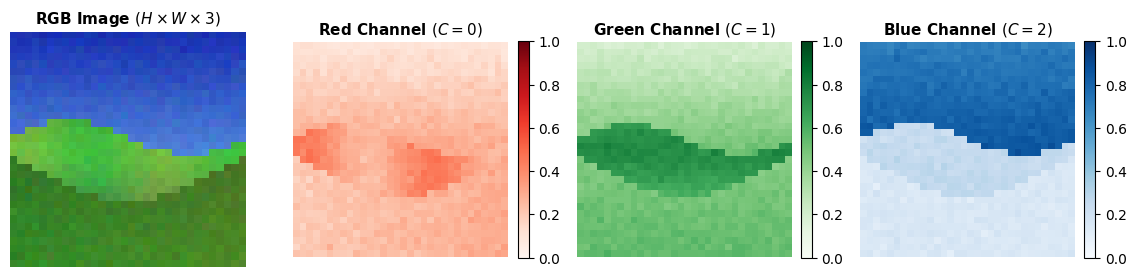

In [3]:
# RGB画像テンソルとチャネル分解の可視化
from common.computer_vision import ImageData, generate_figure_image_representation
import matplotlib.pyplot as plt

fig = generate_figure_image_representation()
plt.show()


### チャネル分解の観察
上図は、合成自然風景画像に対するRGBチャネル分解を示しています：
- **Redチャネル ($C=0$)**: 空の領域では低く、地表や日向の領域で相対的に強い値を示します。
- **Greenチャネル ($C=1$)**: 植生（丘陵地）において極めて高い応答を示します。
- **Blueチャネル ($C=2$)**: 空（大気散乱による青色光）において最も強い強度を示します。

各チャネルは同一の空間グリッド $(H \times W)$ 上に緊密にアラインされており、空間的な同一位置における異なる物理的・光学的属性を記録しています。


## 3. 無構造MLPの破綻と構造的帰納バイアスの必然性

前章（第6章〜第9章）で扱った標準的な全結合多層パーセプトロン（MLP）を画像データに適用することを考えます。

### 1. 次元の呪いと重みパラメータ数の爆発
$1000 \times 1000$ ピクセルの標準的なカラー画像（約 1 メガピクセル）を入力とするネットワークを想定します：
- 入力次元数：
  $$D = H \times W \times C = 1000 \times 1000 \times 3 = 3 \times 10^6$$
- 第1隠れ層のユニット数を控えめに $M_1 = 1000$ と設定した場合の重みパラメータ数：
  $$W_1 = D \times M_1 = (3 \times 10^6) \times 10^3 = 3 \times 10^9 \quad (30\text{億個})$$

バイアスを含まない第1層だけで 30億個もの浮動小数点パラメータが必要となり、以下の致命的課題が生じます：
1. **メモリ制約**: 単精度浮動小数点（float32 = 4バイト）で $3 \times 10^9 \times 4 \text{B} \approx 12 \text{GB}$ のVRAMが第1層の重み行列だけで消費される。
2. **過学習（Overfitting）**: パラメータ数が訓練サンプル数を天文学的に上回り、正則化なしでは汎化が極めて困難になる。

### 2. 置換不変性（Permutation Invariance）の根本的矛盾
全結合層の線形変換は以下のように記述されます：
$$a_k = \sum_{d=1}^D w_{kd} x_d + b_k$$

ここで、画素のインデックス順序に対する任意の固定置換（Permutation） $\pi: \{1, \dots, D\} \to \{1, \dots, D\}$ を考えます。
もしすべての入力ベクトルに対し $\tilde{x}_d = x_{\pi(d)}$ と並べ替え、対応して重み行列の列も $\tilde{w}_{kd} = w_{k \pi(d)}$ と並べ替えれば、活性化の値は完全に同一となります：
$$\sum_{d=1}^D \tilde{w}_{kd} \tilde{x}_d + b_k = \sum_{d=1}^D w_{k \pi(d)} x_{\pi(d)} + b_k = a_k$$

すなわち、**全結合MLPは入力変数の空間的配置（2次元グリッド上の隣接関係）に関する知識を一切持たず、任意の順序並べ替えに対して数学的に同値（Permutation Invariant）**です。
しかし、人間にとって画素をランダムに並べ替えた画像は視覚的構造が完全に破壊された無意味な砂嵐に見えます。画像認識において「どのピクセルとどのピクセルが隣り合っているか」という幾何学的トポロジーは極めて重要であり、MLPはこの強力な先験的構造を完全に捨て去ってしまっています。

### 3. 独立一様ノイズと自然画像多様体の希薄性
もし各ピクセルの強度が独立同分布（i.i.d.）の一様分布 $\mathcal{U}(0, 1)$ に従ってランダムに決定される場合、生成される画像は純粋な白色ノイズ（砂嵐）となります。
$H \times W$ 次元の巨大な画像空間 $\mathbb{R}^{H \times W}$ の中で、意味のある「自然画像（Natural Images）」が占める領域は、極めて低次元かつ滑らかな**多様体（Manifold）**上に限定されています。


## 4. 自然画像の局所空間相関（Spatial Autocorrelation）の定式化と検証

自然画像が持つ最も基本的かつ普遍的な統計的性質は、**近接するピクセル間の強い正の相関（Local Spatial Correlation）**です。

### 空間自己相関関数の定義
水平方向の空間ラグ（Lag: 画素間距離）を $\Delta x$ とし、画像全体の平均輝度を $\mu = \mathbb{E}[I(x, y)]$、分散を $\sigma^2 = \mathbb{V}[I(x, y)]$ とします。
このとき、1次元水平空間自己相関関数（Horizontal Spatial Autocorrelation Function） $C(\Delta x)$ は以下のように定義されます：

$$C(\Delta x) = \frac{\mathbb{E}_{x, y} \left[ \{I(x, y) - \mu\} \{I(x + \Delta x, y) - \mu\} \right]}{\sigma^2}$$

### 数学的性質
1. **原点での正規化**:
   $$C(0) = \frac{\mathbb{E}[\{I(x, y) - \mu\}^2]}{\sigma^2} = \frac{\sigma^2}{\sigma^2} = 1.0$$
2. **自然画像における単調減衰**:
   物体表面のテクスチャや照明は空間的に連続であるため、$\Delta x$ が小さい近傍では $C(\Delta x) \approx 1.0$ となり、距離 $\Delta x$ の増大に伴って緩やかに減衰します。
3. **画素置換画像および白色ノイズにおける急峻な消失**:
   ピクセルをランダムに置換した画像、あるいは独立な白色ノイズ画像では、任意の $\Delta x \ge 1$ に対してピクセル値が独立となるため：
   $$\mathbb{E}[(I(x, y) - \mu)(I(x + \Delta x, y) - \mu)] = \mathbb{E}[I(x, y) - \mu] \cdot \mathbb{E}[I(x + \Delta x, y) - \mu] = 0 \implies C(\Delta x) \approx 0$$


Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/10/result/fig_10_spatial_correlation.png
Figure saved successfully to: /home/student/Documents/GitHub/my_DeepLearning/result/fig_10_spatial_correlation.png


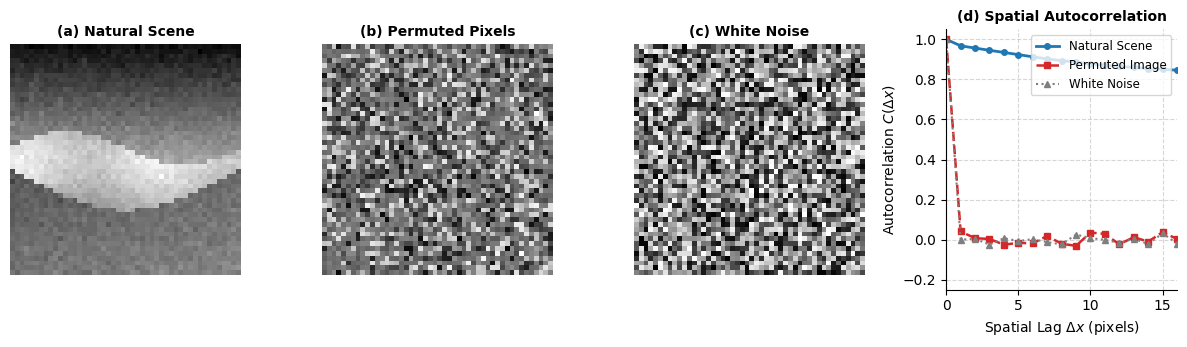

In [4]:
# 自然画像 vs 画素置換画像 vs 白色ノイズの自己相関比較実験
from common.computer_vision import generate_figure_spatial_correlation
import matplotlib.pyplot as plt

fig = generate_figure_spatial_correlation()
plt.show()


### 実験結果の数理的分析

上図の4つのパネルから、以下の統計的知見が明確に実証されます：
1. **Panel (a) 自然風景画像**:
   - 空のグラデーションや丘陵地の表面など、局所的に滑らかな連続構造を持っています。
2. **Panel (b) 画素置換画像 (Permuted Pixels)**:
   - 全ピクセルの1次元ヒストグラム（輝度分布）は自然画像と**厳密に同一**であるにもかかわらず、2次元の空間配置が破壊された結果、視覚的セマンティクスは完全に消失しています。
3. **Panel (c) 白色ノイズ (White Noise)**:
   - 各ピクセルが独立にサンプリングされており、空間相関は一切存在しません。
4. **Panel (d) 空間自己相関曲線 $C(\Delta x)$**:
   - **自然画像（青線）**: $\Delta x = 1$ で $C(1) > 0.85$ という極めて強い正の相関を示し、距離が離れるにつれて滑らかに減衰します。
   - **画素置換画像（赤点線） & 白色ノイズ（灰点線）**: $\Delta x \ge 1$ で即座に 0 近傍へと急降下します。

この結果は、**「自然画像の本質は画素値の周辺分布（ヒストグラム）ではなく、近接画素間の空間的相互関係にある」**という事実を決定的に物語っています。


## 5. 畳み込みネットワーク（CNN）の設計原理への架橋

自然画像の局所空間相関と並進対称性をモデルに組み込むために考案されたのが、**畳み込みニューラルネットワーク（CNN）**です。
CNNは、以下の3つの本質的な**帰納バイアス（Inductive Bias）**をアーキテクチャとして直接組み込みます：

### 1. 局所受容野 (Local Receptive Fields)
- 全結合層のようにすべての入力ピクセルと結合するのではなく、各隠れユニットは小さな局所領域（例: $3 \times 3$ や $5 \times 5$ の受容野）のピクセルのみと結合します。
- **根拠**: 空間自己相関分析が示した通り、遠く離れたピクセル同士の直接の統計的依存度は低く、局所的なパッチ内の相関が支配的であるため。

### 2. 重み共有 (Weight Sharing / Parameter Sharing)
- 同一の受容野サイズを持つフィルタ（カーネル）を画像全体にわたってスライド（畳み込み）させ、すべての位置で同一の重みパラメータを共有します。
- **根拠**: エッジやコーナー、テクスチャなどの低次特徴量は、画像の中央に現れても隅に現れても同一の統計的意味を持ちます。重みを共有することで、パラメータ数を劇的に削減（例: 30億個から数千個へ）し、統計的推定効率を最大化します。

### 3. 並進等変性 (Translation Equivariance)
- 入力画像中の物体が平行移動した場合、特徴マップ上の活性化パターンも対応して同一量だけ平行移動します。
- 入力のシフト演算子を $T_s$、畳み込み演算を $f$ とすると：
  $$f(T_s(\mathbf{x})) = T_s(f(\mathbf{x}))$$
- これにより、物体が画像内のどこに出現しても同じ特徴検出器によって確実に捉えることができます。

---

次節 **10.2 Convolutional Filters** では、これら局所受容野、重み共有、並進等変性を数学的に厳密に定式化した「畳み込み（Cross-Correlation）演算」「パディング」「ストライド」「プーリング」の数理と実装を掘り下げます。


In [5]:
# 共通モジュールの動作確認とアサーション検証
import numpy as np
from common.computer_vision import ImageData, PixelPermutation

# 1. 画像生成と形状確認
H, W = 32, 48
img = ImageData.create_synthetic_natural_scene(height=H, width=W, seed=42)
assert img.shape == (H, W, 3), f"Expected shape ({H}, {W}, 3), got {img.shape}"
assert 0.0 <= img.min() and img.max() <= 1.0, "Pixel values must be in [0, 1]"

# 2. グレースケール変換の検証 (ITU-R BT.601)
gray = ImageData.to_grayscale(img)
assert gray.shape == (H, W), f"Expected shape ({H}, {W}), got {gray.shape}"
expected_sample = 0.299 * img[0, 0, 0] + 0.587 * img[0, 0, 1] + 0.114 * img[0, 0, 2]
assert np.isclose(gray[0, 0], expected_sample, atol=1e-5), "Grayscale conversion mismatch!"

# 3. 空間自己相関の数学的性質の検証
lags, ac_natural = ImageData.compute_spatial_autocorrelation(gray, max_lag=10)
assert np.isclose(ac_natural[0], 1.0), f"Autocorrelation at lag 0 must be 1.0, got {ac_natural[0]}"
assert ac_natural[1] > 0.75, f"Natural image lag-1 autocorrelation should be high, got {ac_natural[1]}"

# 4. 置換による空間相関の破壊の検証
perm_gray, perm = PixelPermutation.permute_image(gray, seed=42)
_, ac_perm = ImageData.compute_spatial_autocorrelation(perm_gray, max_lag=10)
assert np.isclose(ac_perm[0], 1.0), "Permuted lag 0 must be 1.0"
assert abs(ac_perm[1]) < 0.15, f"Permuted image lag-1 correlation should drop near 0, got {ac_perm[1]}"

# 5. ヒストグラム保存の検証
np.testing.assert_allclose(np.sort(gray.ravel()), np.sort(perm_gray.ravel()))

print("All mathematical & algorithmic verifications passed successfully!")


All mathematical & algorithmic verifications passed successfully!


## 6. まとめと第10章第10.2節への展望

### 本節（10.1）の主要な学習到達目標と成果
1. **コンピュータビジョンの全体像と10大タスク**:
   - 画像分類、物体検出、セグメンテーション、画像合成、深度予測、3次元復元など、広範なビジョンタスクの数学的入出力構造を整理しました。
2. **画像データの構造的特徴**:
   - ピクセルグリッド $(H \times W \times C)$、ボクセル、動画テンソルなどの高次元マルチチャネルテンソル表現と輝度変換を定義しました。
3. **無構造MLPの破綻理由の数理的解明**:
   - 次元の呪い（$3 \times 10^9$ パラメータの爆発）および置換不変性（空間構造の無視）という2つの決定的弱点を明確化しました。
4. **自然画像の局所空間相関の実証**:
   - 自己相関関数 $C(\Delta x)$ を導出し、自然画像が持つ近接画素間の強い統計的結合と、画素置換によるその破壊を数値・可視化の両面から実証しました。
5. **CNNの帰納バイアスの必然性**:
   - 局所受容野、重み共有、並進等変性が、画像モダリティの統計的性質に対する最適かつ不可欠なアーキテクチャであることを確認しました。

---

### 次節への展開
次は **第10章 10.2 畳み込みフィルタ (Convolutional Filters)** に進みます。
1次元および2次元の畳み込み演算（式 10.1, 10.2）、エッジ検出フィルタ（式 10.3, 10.4）、パディング（Figure 10.5）、ストライド、マルチチャネル畳み込み（Figure 10.6, 10.7）、プーリング（Figure 10.8）などの厳密な数学的導出と実装・可視化を展開します。
